# Day 1 - 세션 3 : CNN-LSTM으로 "시간의 흐름"까지 학습하기

세션 2에서 우리는 1D-CNN으로 베어링 진동 신호의 FFT 스펙트럼을 분류했고, **테스트 Accuracy 100%** 라는 결과를 얻었습니다.

그런데 정말로 1D-CNN만 있으면 충분할까요? 이번 세션에서는 **LSTM**을 추가한 **CNN-LSTM** 구조를 만들어보고,
1D-CNN과 비교하면서 LSTM이 어떤 역할을 하는지, 그리고 언제 진짜로 유용한지 살펴봅니다.

## 🎯 오늘의 목표
1. 1D-CNN이 "보지 못하는" 것이 무엇인지 이해한다
2. LSTM의 핵심 직관(기억하고 잊는 네트워크)을 이해한다
3. CNN + LSTM을 연결한 CNN-LSTM 모델을 직접 구현한다
4. 같은 데이터로 1D-CNN과 CNN-LSTM의 성능(Accuracy, Confusion Matrix)을 비교한다
5. 이 비교 결과가 실제 시멘트 공장 설비(분쇄기, 킬른, 송풍기)에 어떤 의미를 갖는지 이야기한다

In [ ]:
# 필요한 라이브러리 불러오기
import re
import platform

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

%matplotlib inline
# 그래프 한글 깨짐 방지 (OS별 한글 폰트 자동 설정)
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위해 랜덤 시드 고정
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 사용 가능한 GPU가 있으면 사용 (CUDA > MPS(Apple Silicon) > CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"사용할 디바이스: {device}")

## STEP 1. 데이터 준비 - 세션 1 전처리 파이프라인 재사용

세션 1, 2에서 만든 전처리 파이프라인(`.mat` 로드 → 슬라이딩 윈도우 → FFT → 정규화)을 그대로 재사용합니다.
이미 검증된 파이프라인이므로, 이번에는 코드만 가져오고 자세한 설명은 생략합니다. (자세한 설명은 `1. Data Preprocessing.ipynb` 참고)

In [2]:
def sliding_window(signal, window_size=2048, step=1024):
    """긴 신호를 (window_size) 크기의 여러 조각으로 잘라낸다."""
    segments = []
    for start in range(0, len(signal) - window_size, step):
        segments.append(signal[start:start + window_size])
    return np.array(segments)


def compute_fft(segment, fs=48000):
    """시간 영역 윈도우를 주파수 영역(FFT)으로 변환한다."""
    n = len(segment)
    fft_vals = np.abs(np.fft.rfft(segment))[:n // 2]
    return fft_vals


def get_de_signal(filepath):
    """.mat 파일에서 DE(Drive End) 채널 신호를 정확한 키로 찾아서 반환한다."""
    m = loadmat(filepath)
    file_num = re.search(r'_(\d+)\.mat$', filepath).group(1)
    de_key = f'X{file_num}_DE_time'
    return m[de_key].squeeze()


# 파일 경로 → 클래스 레이블 매핑 (0: Normal, 1: Inner Race, 2: Outer Race, 3: Ball)
file_label_map = {
    'dataset/raw/Time_Normal_1_098.mat':  0,
    'dataset/raw/IR007_1_110.mat':        1,
    'dataset/raw/IR014_1_175.mat':        1,
    'dataset/raw/IR021_1_214.mat':        1,
    'dataset/raw/OR007_6_1_136.mat':      2,
    'dataset/raw/OR014_6_1_202.mat':      2,
    'dataset/raw/OR021_6_1_239.mat':      2,
    'dataset/raw/B007_1_123.mat':         3,
    'dataset/raw/B014_1_190.mat':         3,
    'dataset/raw/B021_1_227.mat':         3,
}
class_names = ['Normal', 'Inner Race', 'Outer Race', 'Ball']


def load_and_preprocess_cwru_dataset(
    file_label_map, window_size=2048, step=1024, fs=48000,
    test_size=0.2, random_state=42,
):
    """CWRU Bearing 데이터셋 전처리 파이프라인 전체 (세션 1 STEP 7과 동일)."""
    X_list, y_list = [], []
    for filepath, label in file_label_map.items():
        signal = get_de_signal(filepath)
        segments = sliding_window(signal, window_size=window_size, step=step)
        for seg in segments:
            X_list.append(compute_fft(seg, fs=fs))
            y_list.append(label)

    X = np.array(X_list)
    y = np.array(y_list)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [3]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler = load_and_preprocess_cwru_dataset(file_label_map)

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")
print(f"클래스 종류: {class_names}")

X_train_scaled: (3704, 1024)
X_test_scaled : (926, 1024)
클래스 종류: ['Normal', 'Inner Race', 'Outer Race', 'Ball']


## STEP 2. PyTorch 입력 형태로 변환하기

세션 2와 동일하게, `(배치, 채널, 길이)` 형태의 텐서로 변환하고 DataLoader를 만듭니다.

In [4]:
# numpy 배열 → PyTorch tensor 변환
# unsqueeze(1): (N, 1024) → (N, 1, 1024)  (채널 차원 추가)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"X_train_tensor shape: {X_train_tensor.shape}  (배치, 채널, 길이)")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

# Dataset + DataLoader 구성 (배치 크기 32)
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 첫 번째 배치 확인
xb, yb = next(iter(train_loader))
print(f"\n배치 1개 shape: x={xb.shape}, y={yb.shape}")

X_train_tensor shape: torch.Size([3704, 1, 1024])  (배치, 채널, 길이)
y_train_tensor shape: torch.Size([3704])

배치 1개 shape: x=torch.Size([32, 1, 1024]), y=torch.Size([32])


## STEP 3. 공통 학습 함수 준비

세션 2 마지막에 만들었던 `train_and_evaluate()` 함수를 다시 사용합니다.
이 함수에 **1D-CNN**과 **CNN-LSTM** 모델을 각각 넣어서 학습시키면,
"모델 구조만 다르고 나머지 학습 과정은 동일한" 상태에서 두 모델을 공정하게 비교할 수 있습니다.

In [5]:
def train_and_evaluate(model, train_loader, X_test_tensor, y_test, num_epochs=10, lr=1e-3):
    """
    주어진 모델을 학습시키고, 테스트 데이터로 평가한다.

    Parameters
    ----------
    model : 학습할 PyTorch 모델 (nn.Module)
    train_loader : 학습 데이터 DataLoader
    X_test_tensor, y_test : 테스트 입력(tensor)과 정답 레이블(numpy)
    num_epochs : 학습 에폭 수
    lr : learning rate

    Returns
    -------
    model        : 학습이 끝난 모델
    loss_history : 에폭별 평균 loss 리스트
    accuracy     : 테스트 Accuracy
    y_pred       : 테스트 데이터에 대한 예측 클래스
    """
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor.to(device)).argmax(dim=1).cpu().numpy()
    accuracy = accuracy_score(y_test, y_pred)

    return model, loss_history, accuracy, y_pred

## STEP 4. 베이스라인 : 1D-CNN 다시 학습하기

비교의 기준(베이스라인)이 될 1D-CNN 모델을 세션 2와 동일한 구조로 다시 학습시킵니다.

In [6]:
class CNN1D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=9, padding=4)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=9, padding=4)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        # Conv+Pool을 두 번 거치면 길이: 1024 → 512 → 256
        self.fc1 = nn.Linear(32 * 256, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # → (배치, 16, 512)
        x = self.pool(self.relu(self.conv2(x)))   # → (배치, 32, 256)
        x = x.flatten(start_dim=1)                # → (배치, 32*256)
        x = self.relu(self.fc1(x))                # → (배치, 64)
        return self.fc2(x)                        # → (배치, 4)


torch.manual_seed(SEED)
cnn_model = CNN1D(num_classes=4)
cnn_model, cnn_history, cnn_acc, cnn_pred = train_and_evaluate(
    cnn_model, train_loader, X_test_tensor, y_test, num_epochs=10, lr=1e-3
)
print(f"[1D-CNN] 테스트 Accuracy: {cnn_acc * 100:.2f}%")
print(f"[1D-CNN] 최종 Loss: {cnn_history[-1]:.4f}")

[1D-CNN] 테스트 Accuracy: 100.00%
[1D-CNN] 최종 Loss: 0.0001


## STEP 4 결과 : 1D-CNN Confusion Matrix

베이스라인 모델의 Confusion Matrix를 확인합니다. 이 결과가 CNN-LSTM과 비교할 "기준선"이 됩니다.

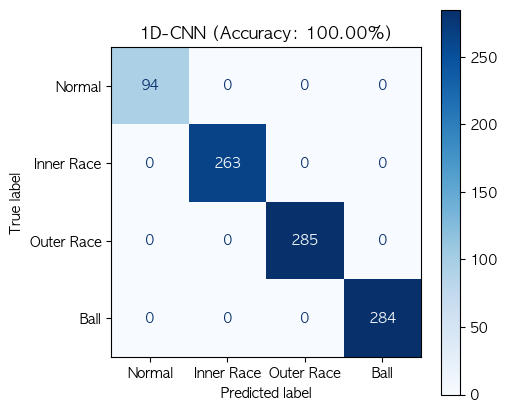

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, cnn_pred, display_labels=class_names, cmap='Blues', ax=ax)
ax.set_title(f"1D-CNN (Accuracy: {cnn_acc*100:.2f}%)")
plt.show()

## STEP 5. CNN-LSTM 구조 이해하기

### 1D-CNN의 한계
- 1D-CNN은 입력된 "한 윈도우" 안에서 패턴(필터)을 찾는 데는 강합니다.
- 하지만 **"이 패턴이 시간이 지나면서 어떻게 변해왔는가"**는 보지 못합니다.
- 예: 베어링이 망가지는 과정은 보통 "약한 이상 징후 → 점점 심해짐 → 고장"처럼
  여러 시점에 걸친 **변화의 흐름**으로 나타납니다. 1D-CNN은 이 흐름을 직접 모델링하지 않습니다.

### LSTM : 기억하는 네트워크
- LSTM(Long Short-Term Memory)의 핵심 직관: **"중요한 건 오래 기억하고, 불필요한 건 잊는다"**
- 두 가지 기억 통로를 가짐
  - **Cell State**: 장기 기억 (오랫동안 유지할 정보)
  - **Hidden State**: 단기 기억 (바로 직전 상태)
- 입력/삭제/출력 게이트가 "무엇을 기억하고, 무엇을 잊고, 무엇을 다음으로 넘길지"를 학습으로 결정합니다.

### CNN-LSTM 연결 구조
```
진동 신호(FFT) 입력
        ↓
  [1D-CNN 블록]   ← 로컬 주파수 패턴 추출
        ↓
  [LSTM 블록]     ← 추출된 특징들의 흐름(시퀀스) 학습
        ↓
  [Fully Connected] ← 최종 4클래스 분류
```

### ⚠️ 이번 실습에서의 "시퀀스"란?
이번 노트북에서 LSTM에 들어가는 "시퀀스"는 **여러 날에 걸친 측정값**이 아니라,
**하나의 FFT 윈도우를 CNN이 처리한 뒤 남은 주파수축 방향의 특징 배열**입니다.
즉, "진짜 시간 흐름"이 아니라 "주파수축을 따라가는 흐름"을 LSTM이 학습하는 구조입니다.

→ 슬라이드에서 이야기한 "여러 시점의 변화 추세"를 제대로 활용하려면,
   여러 개의 연속된 윈도우를 하나의 시퀀스로 묶어서 LSTM에 넣는 구조가 필요합니다.
   (이는 Day 4에서 다룰 좀 더 고도화된 파이프라인의 영역입니다)

이 점을 염두에 두고, 아래에서 CNN-LSTM의 성능을 1D-CNN과 비교해봅시다.

In [8]:
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=4, hidden_size=64):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=9, padding=4)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=9, padding=4)
        self.pool = nn.MaxPool1d(kernel_size=2)
        # 추가 pooling: LSTM에 넣기 좋은 시퀀스 길이(64)로 한 번 더 줄인다 (256 → 64)
        self.pool_seq = nn.MaxPool1d(kernel_size=4)
        self.relu = nn.ReLU()

        # LSTM 입력: (배치, 시퀀스 길이=64, 특징 수=32)
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (배치, 1, 1024)
        x = self.pool(self.relu(self.conv1(x)))   # → (배치, 16, 512)
        x = self.pool(self.relu(self.conv2(x)))   # → (배치, 32, 256)
        x = self.pool_seq(x)                      # → (배치, 32, 64)

        x = x.permute(0, 2, 1)                    # → (배치, 64, 32)  (LSTM 입력 형태)

        _, (h_n, _) = self.lstm(x)                # h_n: (1, 배치, hidden_size)
        x = h_n[-1]                                # → (배치, hidden_size)  : 시퀀스를 끝까지 읽은 후의 최종 상태

        return self.fc(x)                          # → (배치, 4)


cnn_lstm_model = CNNLSTM(num_classes=4)
print(cnn_lstm_model)

dummy_input = torch.randn(4, 1, 1024)
dummy_output = cnn_lstm_model(dummy_input)
print(f"\n더미 입력 shape : {dummy_input.shape}")
print(f"더미 출력 shape : {dummy_output.shape}  (배치 4개 × 클래스 4개 점수)")

CNNLSTM(
  (conv1): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
  (conv2): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (pool_seq): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

더미 입력 shape : torch.Size([4, 1, 1024])
더미 출력 shape : torch.Size([4, 4])  (배치 4개 × 클래스 4개 점수)


## STEP 6. CNN-LSTM 학습하기

같은 `train_and_evaluate()` 함수를 사용하되, LSTM은 1D-CNN보다 학습이 느리게 수렴하는 경우가 많아서
에폭 수와 learning rate를 조금 더 크게 줍니다 (30 에폭, lr=0.002).

In [9]:
torch.manual_seed(SEED)
cnn_lstm_model = CNNLSTM(num_classes=4)
cnn_lstm_model, lstm_history, lstm_acc, lstm_pred = train_and_evaluate(
    cnn_lstm_model, train_loader, X_test_tensor, y_test, num_epochs=30, lr=2e-3
)
print(f"[CNN-LSTM] 테스트 Accuracy: {lstm_acc * 100:.2f}%")
print(f"[CNN-LSTM] 최종 Loss: {lstm_history[-1]:.4f}")

[CNN-LSTM] 테스트 Accuracy: 99.14%
[CNN-LSTM] 최종 Loss: 0.0189


## STEP 7. 1D-CNN vs CNN-LSTM 비교

이제 두 모델을 나란히 비교해봅니다.

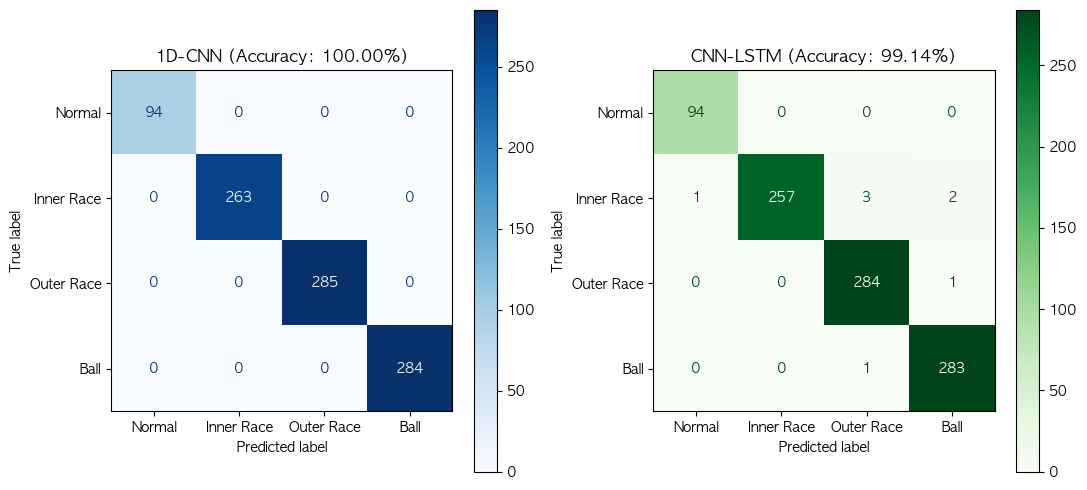

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_predictions(y_test, cnn_pred, display_labels=class_names, cmap='Blues', ax=axes[0])
axes[0].set_title(f"1D-CNN (Accuracy: {cnn_acc*100:.2f}%)")

ConfusionMatrixDisplay.from_predictions(y_test, lstm_pred, display_labels=class_names, cmap='Greens', ax=axes[1])
axes[1].set_title(f"CNN-LSTM (Accuracy: {lstm_acc*100:.2f}%)")

plt.tight_layout()
plt.show()

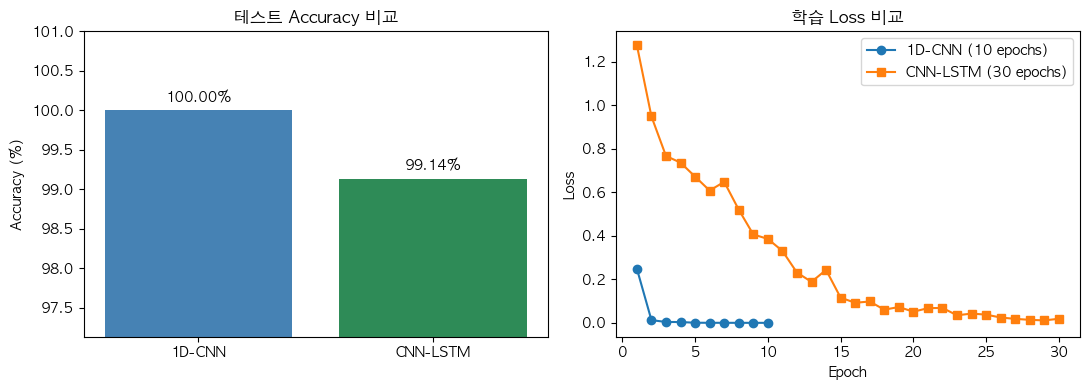

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

accs = [cnn_acc * 100, lstm_acc * 100]
axes[0].bar(['1D-CNN', 'CNN-LSTM'], accs, color=['steelblue', 'seagreen'])
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(min(accs) - 2, 101)
axes[0].set_title('테스트 Accuracy 비교')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.1, f"{v:.2f}%", ha='center')

axes[1].plot(range(1, len(cnn_history) + 1), cnn_history, marker='o', label='1D-CNN (10 epochs)')
axes[1].plot(range(1, len(lstm_history) + 1), lstm_history, marker='s', label='CNN-LSTM (30 epochs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('학습 Loss 비교')
axes[1].legend()

plt.tight_layout()
plt.show()

## STEP 8. 결과 해석 : "LSTM을 추가하면 항상 더 좋아질까?"

위 결과를 보면, CWRU 데이터셋에서는 1D-CNN만으로도 이미 (거의) 완벽한 Accuracy를 달성했기 때문에
CNN-LSTM이 그보다 더 나아지기는 어렵습니다. 오히려 구조가 복잡해진 만큼 학습이 더 오래 걸리거나,
약간의 성능 변화가 나타날 수 있습니다.

**이게 "LSTM이 쓸모없다"는 뜻은 아닙니다.** 슬라이드에서 이야기했듯,
LSTM의 진짜 가치는 **"여러 시점에 걸친 변화 추세"**를 학습하는 데 있습니다.
- 베어링이 "정상 → 약한 이상 → 심한 이상 → 고장"으로 진행되는 과정을 여러 윈도우의 시퀀스로 학습한다면
- 또는 진동 외에도 온도, 전류 등 여러 센서값의 시간 추세를 함께 학습한다면

이런 상황에서는 CNN-LSTM(또는 LSTM 계열 모델)이 1D-CNN보다 분명한 이점을 가질 수 있습니다.

### 🏭 시멘트 공장 실설비 적용 맥락
CNN 기반 접근법은 실제 시멘트 공장 설비에서도 검증된 바 있습니다 (Liang et al., 2024):

| 설비 | 고장 유형 | 진단 정확도 |
|---|---|---|
| 롤러 프레스 | 내륜(Inner Race) 결함 | 94.64% |
| 원심팬 | 불균형 결함 | 97.62% |
| 메인 배기팬 | 외륜(Outer Race) 결함 | 95.43% |

CWRU보다 노이즈가 많은 실제 현장 데이터에서는 1D-CNN만으로 94~98% 수준의 정확도가 나옵니다.
이런 상황에서는 CNN-LSTM처럼 "추세"를 함께 보는 구조가 추가적인 개선을 줄 가능성이 더 높아집니다.
→ 분쇄기, 킬른, 송풍기 등 회전기계의 장기 추세 모니터링에 CNN-LSTM 구조를 적용하는 것이 Day 1의 최종 산출물 방향입니다.

### 🔄 한 가지 더 - "정상"의 기준은 고정돼 있지 않다

오늘 만든 모델은 "이 데이터의 정상/고장 패턴"을 학습한 결과입니다. 그런데 실제 설비는
부하, 속도, 투입 원료 등 운전 조건이 바뀌면 진동의 "정상" 패턴 자체가 달라질 수 있습니다.

→ 한 번 학습한 모델을 계속 그대로 쓰면, 운전 조건이 달라졌을 때 정상 신호를 고장으로(또는 그 반대로)
잘못 판단할 위험이 있습니다. 따라서 실무에서는 **주기적으로 최신 데이터를 모아 모델을 재학습**하거나,
운전 조건별로 모델/기준을 나누는 접근이 함께 고려되어야 합니다.

## STEP 9. 모델 저장

학습된 CNN-LSTM 모델을 다음 단계(또는 실무 적용)에서 다시 불러올 수 있도록 저장합니다.

In [12]:
import os

os.makedirs('models', exist_ok=True)
torch.save(cnn_lstm_model.state_dict(), 'models/cnn_lstm.pt')
print("저장 완료: models/cnn_lstm.pt")

저장 완료: models/cnn_lstm.pt


## STEP 10. 실습 - 하이퍼파라미터 바꿔서 실험해보기

`train_and_evaluate()` 함수를 그대로 활용해서, CNN-LSTM의 `hidden_size`를 바꿔보고
Accuracy/Loss가 어떻게 달라지는지 직접 확인해보세요.

In [13]:
# 🎯 실습: hidden_size를 128로 늘려서 CNN-LSTM을 다시 학습해보고,
# 기존 (hidden_size=64) 결과와 Accuracy를 비교해보세요.

torch.manual_seed(SEED)
cnn_lstm_128 = CNNLSTM(num_classes=4, hidden_size=128)
cnn_lstm_128, history_128, acc_128, pred_128 = train_and_evaluate(
    cnn_lstm_128, train_loader, X_test_tensor, y_test, num_epochs=30, lr=2e-3
)

print(f"CNN-LSTM (hidden_size=64)  → Accuracy: {lstm_acc * 100:.2f}%")
print(f"CNN-LSTM (hidden_size=128) → Accuracy: {acc_128 * 100:.2f}%")

CNN-LSTM (hidden_size=64)  → Accuracy: 99.14%
CNN-LSTM (hidden_size=128) → Accuracy: 99.57%
